# Exercise: Using `matplotlib` to plot 

Having one variable on a chart is good, but is two better? In this exercise, you'll practice adding two variables to the same chart. You will also learn how to create a chart that has two different graphs on it on the same figure!

**Download historical data for 2 years from one ticker**

Use the YFinance package to download 2 years of data for any ticker you'd like. 

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
stock_ticker = "000660.KS"
start_date = "2024-05-01"  # use format YYYY-MM-DD
end_date = "2026-05-11"

data = yf.download(
    tickers=stock_ticker, start=start_date, end=end_date
)  # replace ... inside this function with the correct parameters in order to get your data

[*********************100%***********************]  1 of 1 completed


In [5]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,000660.KS,000660.KS,000660.KS,000660.KS,000660.KS
Date,,,,,
2026-04-30,1286000.0,1325000.0,1286000.0,1312000.0,3342342
2026-05-04,1447000.0,1450000.0,1333000.0,1339000.0,5776641
2026-05-06,1601000.0,1614000.0,1557000.0,1590000.0,6631934
2026-05-07,1654000.0,1665000.0,1567000.0,1622000.0,5860618
2026-05-08,1686000.0,1689000.0,1591000.0,1591000.0,4278087


**Calculate the 20-day and 50-day moving average**

Use Pandas methods to calculate the 20-day and 50-day moving averages for your ticker.

In [6]:
data["MA_20"] = data["Close"].rolling(window=20).mean()
data["MA_50"] = data["Close"].rolling(window=50).mean()

In [8]:
print("MA_20:\n", data["MA_20"].tail(), "\n")
print("MA_50:\n", data["MA_50"].tail(), "\n")

MA_20:
 Date
2026-04-30    1126450.0
2026-05-04    1155000.0
2026-05-06    1190750.0
2026-05-07    1227650.0
2026-05-08    1260300.0
Name: MA_20, dtype: float64 

MA_50:
 Date
2026-04-30    1.018523e+06
2026-05-04    1.029615e+06
2026-05-06    1.042690e+06
2026-05-07    1.056785e+06
2026-05-08    1.070442e+06
Name: MA_50, dtype: float64 



**Plot the daily and moving average data on the same plot**

Use `matplotlib` and plot all 3 of these variables on the same line plot: closing price, 20-day moving average, and 50-day moving average. 

Make sure to use a different color for each variable. You can also practice adding a title and x-axis and y-axis labels to your chart. Optionally, you can add gridlines. 

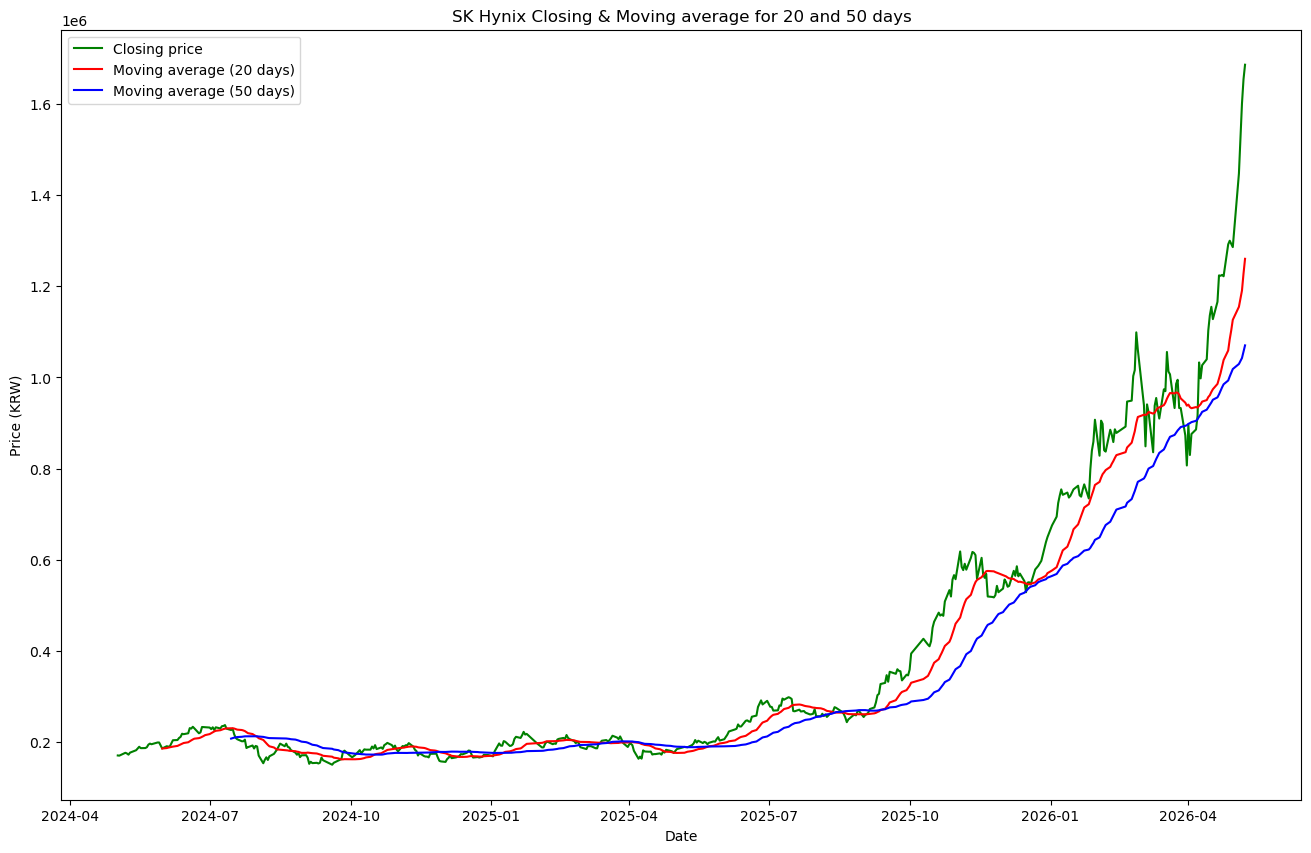

In [11]:
# make plot with 3 lines on it
plt.figure(figsize=(16, 10))
plt.plot(data["Close"].index, data["Close"], label="Closing price", color="green")
plt.plot(
    data["MA_20"].index, data["MA_20"], label="Moving average (20 days)", color="red"
)
plt.plot(
    data["MA_50"].index, data["MA_50"], label="Moving average (50 days)", color="blue"
)
plt.title("SK Hynix Closing & Moving average for 20 and 50 days")
plt.xlabel("Date")
plt.ylabel("Price (KRW)")
plt.legend()
plt.show()

**Create plot with 2 subplots**

In this challenge, you'll be adding two different graphs to the same figure! This means that you'll have two different charts in one image. 

To do this in `matplotlib`, you'll be using the axes attribute of the `figure`. Recall that the `figure` is the canvas on which you draw your plots. You'll use a single figure, but add multiple axes to it, then you can put a different graph in each axes. 

Note that you're creating not just a `fig` like before, but now you're creating both a `fig` and `axes`:
```python
fig, ax = plt.subplots( num_subplots, figsize=(x,y), sharerx=True/False)
```

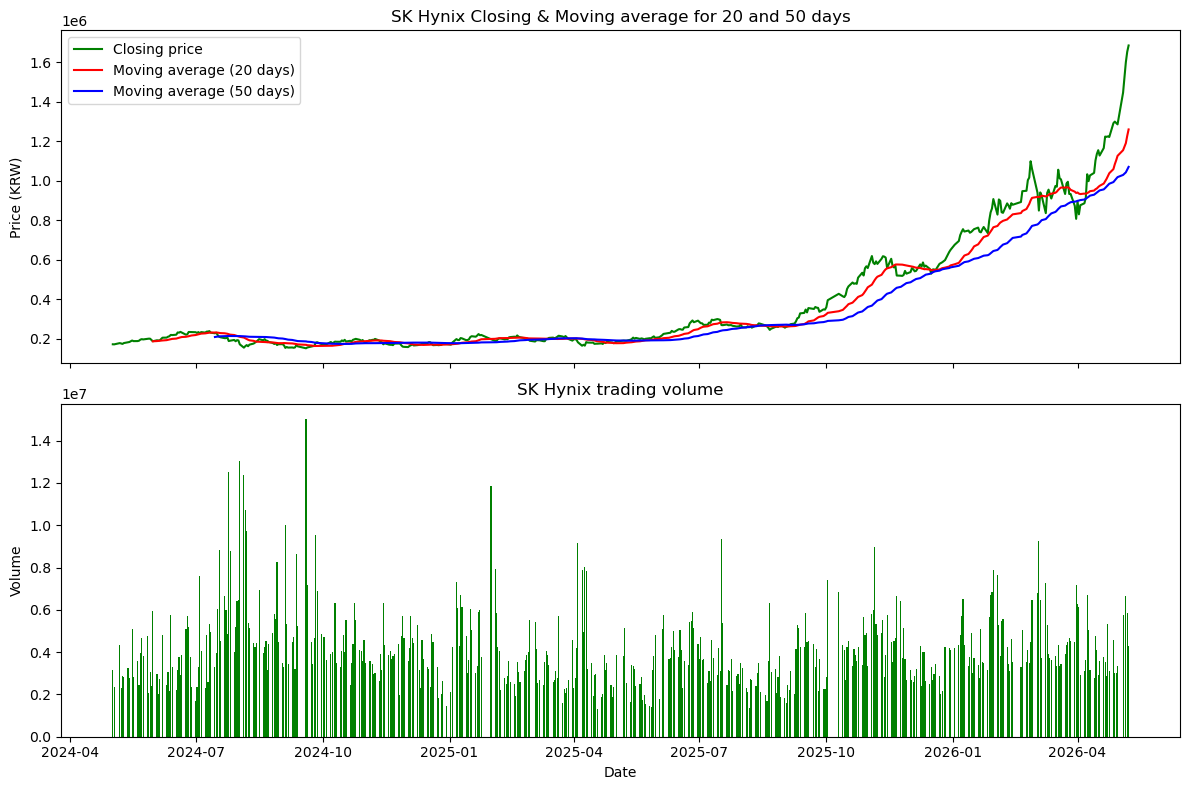

In [15]:
# first create a figure with two axes
fig, ax = plt.subplots(
    2, figsize=(12, 8), sharex=True
)  # this is the foundation of creating multiple charts on one figure

# ax[0] creates the first chart. You'll want to add all 3 line plots to it:
ax[0].plot(
    data["Close"].squeeze().index,
    data["Close"].squeeze(),
    label="Closing price",
    color="green",
)
ax[0].plot(
    data["MA_20"].index,
    data["MA_20"].squeeze(),
    label="Moving average (20 days)",
    color="red",
)
ax[0].plot(
    data["MA_50"].index,
    data["MA_50"].squeeze(),
    label="Moving average (50 days)",
    color="blue",
)
ax[0].set_title("SK Hynix Closing & Moving average for 20 and 50 days")
ax[0].set_ylabel("Price (KRW)")
ax[0].legend()

# ax[1] creates the second, separate chart on the same figure
ax[1].bar(data.index, data["Volume"].squeeze(), label="Trading Volume", color="green")
ax[1].set_title("SK Hynix trading volume")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()